In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
from pathlib import Path
from scipy.interpolate import make_smoothing_spline
from statsmodels.stats.multitest import multipletests


from joblib import Parallel, delayed


# Load data

In [50]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
metabolomics_folder = data_folder / 'D_big_screen'
figure_folder = repo_folder / 'figures'/'3_big_screen'


In [51]:
normalization = 'TIC'
median_fn = metabolomics_folder / f'G_median_z_scores_{normalization}_norm_keio.csv'
df_data = pd.read_csv(median_fn)
df_data.rename(columns={'Z-score median': 'Median Z-score'}, inplace=True)

ionMz_annotation_fn = metabolomics_folder / 'H_ionMz_annotation.csv'
df_ionMz = pd.read_csv(ionMz_annotation_fn)

sample_metadata_fn = metabolomics_folder / 'I_sample_metadata_keio.csv'
df_sample_metadata = pd.read_csv(sample_metadata_fn)

auc_df = pd.read_csv(metabolomics_folder / 'J_auc_z_scores_keio.csv')

lam = 10
xval = 'AUC OD'
distance_fn = metabolomics_folder / f'K_timecurve_comparison_{normalization}_norm_lam_{lam}_{xval}.csv'
dis_df = pd.read_csv(distance_fn, index_col=0)




In [52]:
df_mz = df_data.merge(df_ionMz, on='ionMz', how='left')
dis_mz = dis_df.merge(df_ionMz, on='ionMz', how='left')

In [53]:
df = df_mz.merge(df_sample_metadata, on=['Batch-Tube', 'Timepoint'], how='left')

In [54]:
df.sort_values(by=['Batch-Tube', 'ionMz', 'Hours'], inplace=True)

In [55]:
dis_mz.loc[dis_mz.Strain == 'putP'].sort_values(by='Rel. abs. distance', ascending=False).head(10)

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names
4280,putP,114.0560,12.802219,12.802219,4.923788,4.923788,0.633606,0.135603,0.384604,putP,WT,0.0,0.0,Proline,C00148,Proline
4310,putP,133.0508,3.249813,-3.151449,0.365388,-0.354328,0.098008,0.126859,0.112434,putP,WT,0.0,0.0,Deoxyribose,C01801;C04039;C04272;C06257,"(R)-2,3-Dihydroxy-isovalerate / 1-Deoxy-xylulo..."
4397,putP,203.0348,3.192531,3.107843,0.590252,0.574594,0.201744,0.168027,0.184885,putP,WT,0.0,0.0,"1,4-Dihydroxy-2-naphthoate",C03657,"1,4-Dihydroxy-2-naphthoic acid"
4422,putP,240.0514,3.124610,-3.095194,0.319963,-0.316950,0.074390,0.130412,0.102401,putP,WT,0.0,0.0,"N-(2,3-Dihydroxybenzoyl)-L-serine",C04204,"2,3-Dihydroxybenzoylserine"
4373,putP,178.0510,2.910111,-2.850233,0.166545,-0.163118,0.035972,0.078488,0.057230,putP,WT,0.0,0.0,N-Acetylanthranilate,C06332,N-Acetylanthranilate
4325,putP,147.0664,2.640479,-2.549307,0.306200,-0.295627,0.113785,0.118143,0.115964,putP,WT,0.0,0.0,"(R) 2,3-Dihydroxy-3-methylvalerate",C00522;C06007,"(R) 2,3-Dihydroxy-3-methylvalerate / (R)-Pantoate"
4441,putP,275.1015,2.626515,2.626515,0.530019,0.530019,0.199691,0.203900,0.201796,putP,WT,0.0,0.0,5-Amino-6-(1-D-ribitylamino)uracil,C04732,5-Amino-6-ribitylamino uracil / 5-amino-6-(rib...
4426,putP,253.0119,2.561356,-2.450227,0.355041,-0.339637,0.114902,0.162327,0.138614,putP,WT,0.0,0.0,Shikimate 3-phosphate,C03175,Shikimate 3-phosphate
4284,putP,116.0356,2.235706,-1.994657,0.644347,-0.574875,0.280152,0.296263,0.288207,putP,WT,0.0,0.0,Aspartate semialdehyde,C00441;C03508;C20250,(Z)-2-Methyl-peroxyaminoacrylate / 2-Amino-3-o...
4323,putP,146.0460,2.161238,-2.142744,0.380913,-0.377654,0.080324,0.272172,0.176248,putP,WT,0.0,0.0,Glutamate,C00025;C00217;C00979,Glutamate / Glutamic acid / O-Acetylserine


# Drop slow strains

In [56]:
# Slow growing strains
drop_strains = ['dppB', 'tolC', 'ptsG',]
auc_df = auc_df[~auc_df.Strain.isin(drop_strains)]
dis_mz = dis_mz[~dis_mz.Strain.isin(drop_strains)]
df = df[~df.Strain.isin(drop_strains)]

# Thresholds

In [57]:
max_pval = 0.005
min_effect = 3

# Plot AUC vs AUC

## Get significance from timecurve comparisons

In [58]:
strain_ionMz_to_pval = dis_mz.set_index(['Strain', 'ionMz'])['p-value rel'].to_dict()
strain_ionMz_to_distance = dis_mz.set_index(['Strain', 'ionMz'])['Rel. distance'].to_dict()

In [59]:
auc_df['Batch'] = auc_df['Batch-Tube'].apply(lambda x: x.split('-')[0])

In [60]:
mean_auc = auc_df.groupby(['Batch', 'Strain', 'ionMz']).agg({'AUC Z-score (AUC OD)': ['mean', 'std']}).reset_index()
mean_auc.columns = ['Batch', 'Strain', 'ionMz', 'Mean AUC Z-score', 'STD AUC Z-score']  

In [61]:
mean_auc['p-value rel'] = mean_auc.apply(lambda row: strain_ionMz_to_pval.get((row['Strain'], row['ionMz']), np.nan), axis=1)
# mean_auc['Significant'] = mean_auc['p-value rel'] < 0.01

# t-test based on AUC

In [62]:
import scipy.stats as st

results = []
all_mZ_ions = auc_df['ionMz'].unique()
for strain in auc_df['Strain'].unique():
    if strain == 'WT':
        continue
    dfs = auc_df[auc_df['Strain'].isin([strain, 'WT'])]
    for ion in all_mZ_ions:
        dfi = dfs.loc[dfs['ionMz'] == ion]
        if dfi['Strain'].nunique() < 2:
            continue
        wt_values = dfi.loc[dfi['Strain'] == 'WT', 'AUC Z-score (AUC OD)'].values
        strain_values = dfi.loc[dfi['Strain'] == strain, 'AUC Z-score (AUC OD)'].values
        # Use t-test (or use st.mannwhitneyu for non-parametric)
        stat, pval = st.ttest_ind(strain_values, wt_values, equal_var=False, alternative='two-sided')
        results.append({'ionMz': ion, 'strain': strain, 'statistic': stat, 'pvalue': pval})
ttest_auc_df = pd.DataFrame(results)


In [63]:

for strain in ttest_auc_df['strain'].unique():
    sidx = ttest_auc_df['strain'] == strain
    df_strain = ttest_auc_df[ttest_auc_df['strain'] == strain]
    pvals = ttest_auc_df.loc[sidx, 'pvalue'].values
    reject, pvals_corrected, _, _ = multipletests(pvals,alpha = 0.01, method='fdr_bh')
    ttest_auc_df.loc[sidx, 'pvalue_adj'] = pvals_corrected

# # Correct p-values for multiple testing (FDR)
# ttest_auc_df['p_adj'] = multipletests(ttest_auc_df['pvalue'], method='fdr_bh')[1]


In [64]:
strain_ionMz_to_pval_auc = ttest_auc_df.set_index(['strain', 'ionMz'])['pvalue_adj'].to_dict()



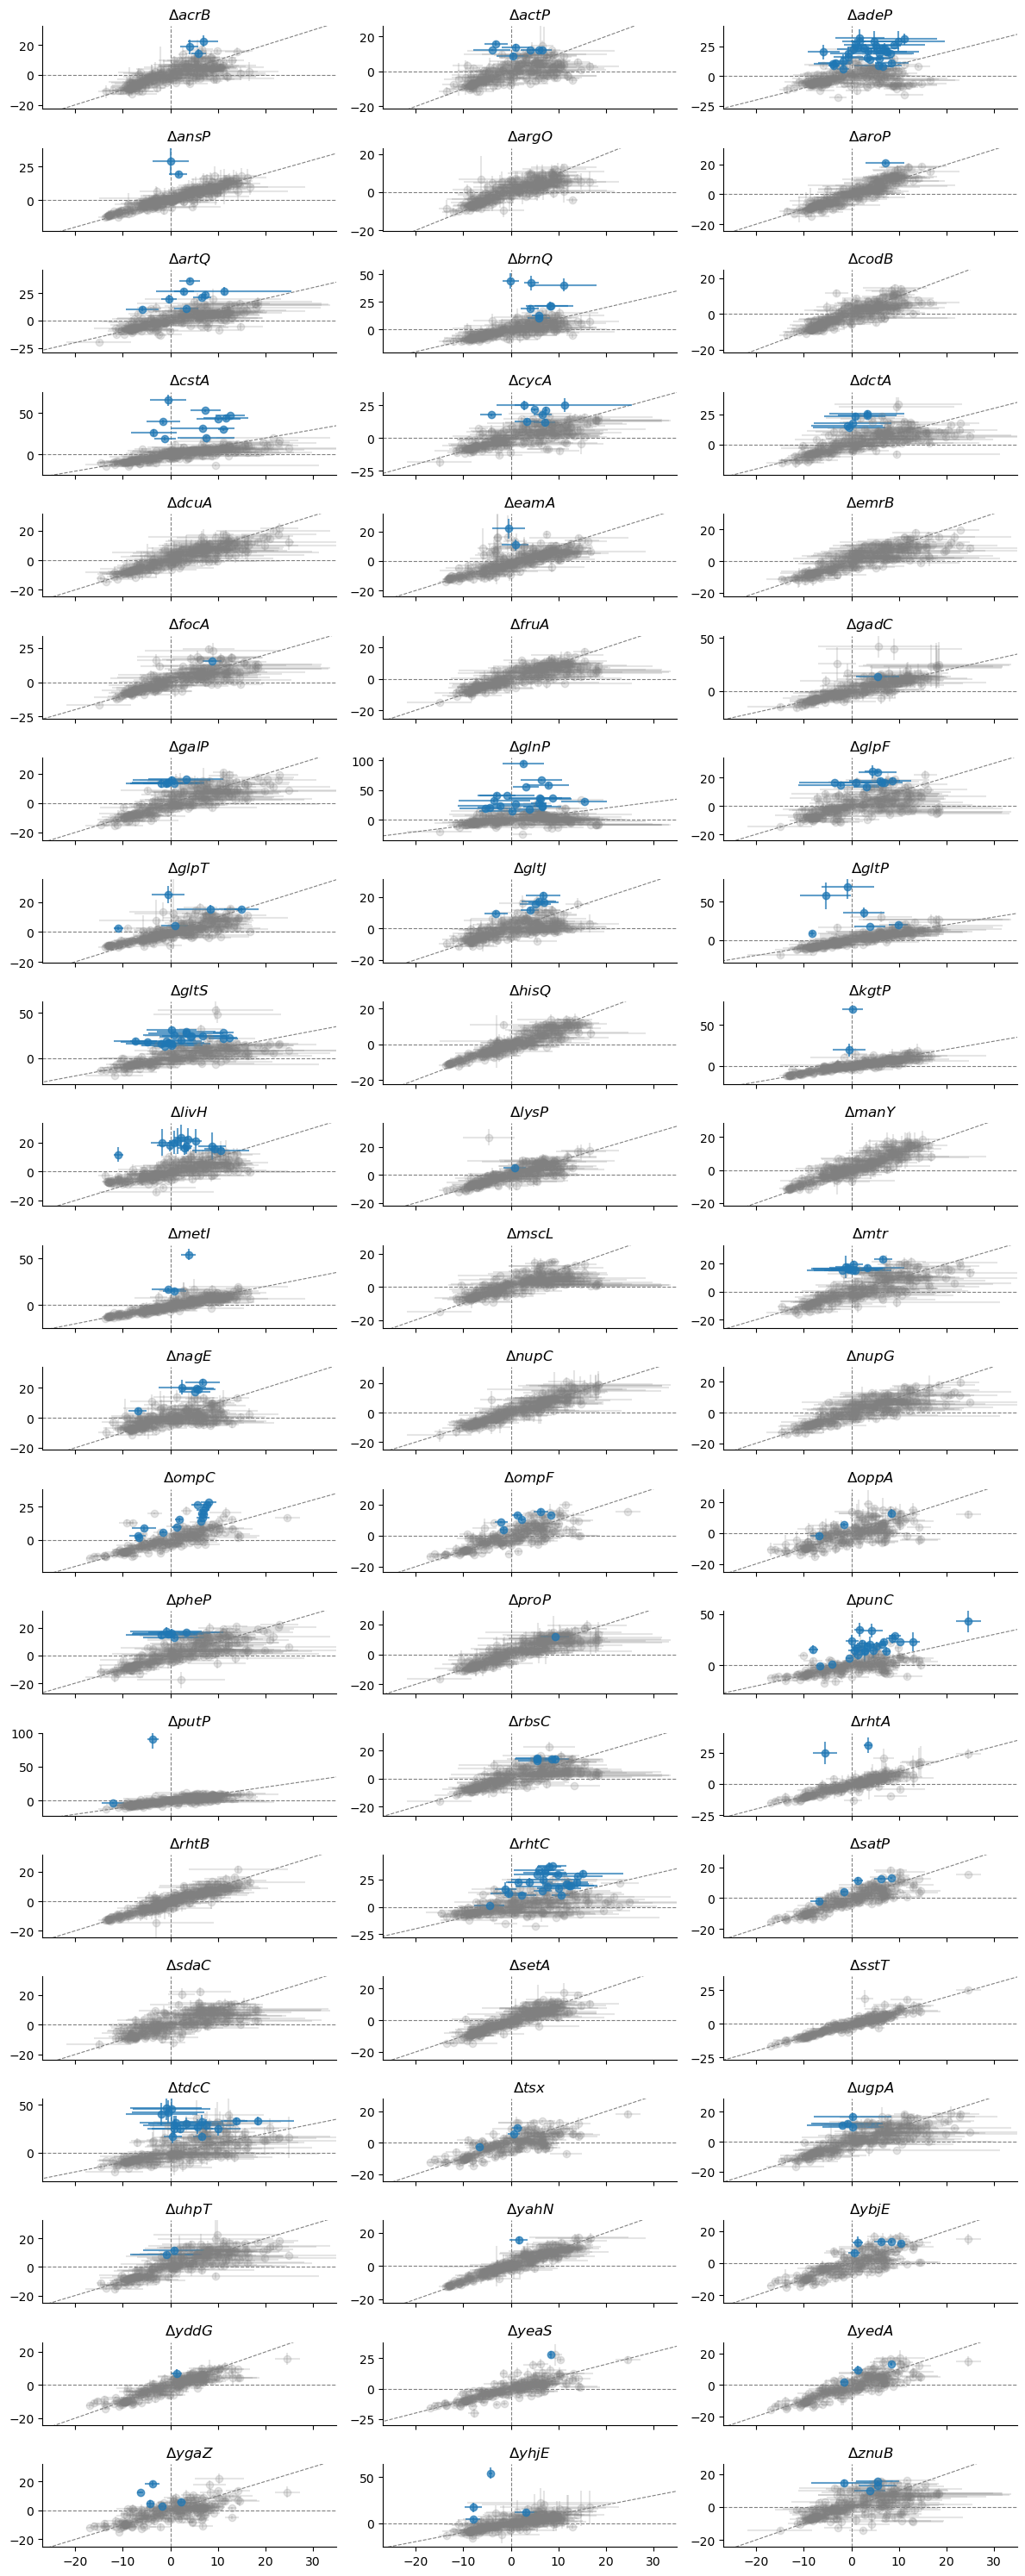

In [65]:
strains = sorted([x for x in mean_auc.Strain.unique() if x!= 'WT'])
fig, axes = plt.subplots(21, 3, figsize=(12,30), sharex=True, sharey=False)
axes = axes.flatten()
for j, strain in enumerate(strains):
    batch = mean_auc.loc[mean_auc.Strain == strain, 'Batch'].values[0]
    dfi = mean_auc.loc[mean_auc.Strain.isin([strain, 'WT']) & (mean_auc.Batch == batch)]
    
    dfi_wide = dfi.pivot(index='ionMz', columns='Strain', values=['Mean AUC Z-score', 'STD AUC Z-score'])
    dfi_wide.columns = [f'{stat}_{s}' for stat, s in dfi_wide.columns]
    dfi_wide = dfi_wide.reset_index()
    for i, row in dfi_wide.iterrows():
        dfi_wide.loc[i, 'Significance'] = (strain_ionMz_to_pval[(strain, row['ionMz'])] < max_pval) and (strain_ionMz_to_distance[(strain, row['ionMz'])] > min_effect)
        dfi_wide.loc[i, 'p-value'] = strain_ionMz_to_pval[(strain, row['ionMz'])]
        dfi_wide.loc[i, 'p-value auc'] = strain_ionMz_to_pval_auc.get((strain, row['ionMz']), np.nan)
    ax = axes[j]
    for sgn in [False, True]:
        subset = dfi_wide[dfi_wide['Significance'] == sgn]
        ax.errorbar(
            x = subset['Mean AUC Z-score_WT'],
            y = subset[f'Mean AUC Z-score_{strain}'],
            xerr=subset['STD AUC Z-score_WT'],
            yerr=subset[f'STD AUC Z-score_{strain}'],
            alpha=0.7 if sgn else 0.2,
            fmt = 'o',
            c = 'C0' if sgn else 'gray',
            mec = 'C0' if sgn else 'gray',
            mfc = 'C0' if sgn else 'gray',
            label='Significant' if sgn else 'Not significant'
        )
    # xrange = [dfi_wide['Mean AUC Z-score_WT'].min()-10, dfi_wide['Mean AUC Z-score_WT'].max()+10]
    yrange = [dfi_wide[f'Mean AUC Z-score_{strain}'].min()-10, dfi_wide[f'Mean AUC Z-score_{strain}'].max()+10]
    # ax.set_xlim(xrange)
    ax.set_ylim(yrange)
    ax.set_title(f'Δ${strain}$')
    ax.plot([-100,100],[-100,100], ls = '--', c = 'gray', lw = 0.8, zorder = 0)
    ax.axvline(0, ls = '--', c = 'gray', lw = 0.8, zorder = 0)
    ax.axhline(0, ls = '--', c = 'gray', lw = 0.8, zorder = 0)
    # ax.set_xticklabels([])
    # ax.set_yticklabels([])
xmin, xmax = mean_auc.loc[mean_auc.Strain.isin(['WT']), 'Mean AUC Z-score'].min(), mean_auc.loc[mean_auc.Strain.isin(['WT']), 'Mean AUC Z-score'].max()
# ymin, ymax = mean_auc.loc[:, 'Mean AUC Z-score'].min(), mean_auc.loc[:, 'Mean AUC Z-score'].max()
# xrange = [dfi_wide['Mean AUC Z-score_WT'].min()-10, dfi_wide['Mean AUC Z-score_WT'].max()+10]
# yrange = [dfi_wide[f'Mean AUC Z-score_{strain}'].min()-10, dfi_wide[f'Mean AUC Z-score_{strain}'].max()+10]
plt.xlim([xmin-10, xmax+10])
# plt.ylim([ymin-10, ymax+10])
sns.despine()
plt.tight_layout()
plt.savefig(figure_folder / 'auc_comparision_all_keio_strains.png', dpi=300)

# Plot timeseries

In [66]:
timeseries_plots_folder = figure_folder / 'timeseries_plots'
timeseries_plots_folder.mkdir(exist_ok=True, parents=True)



In [67]:
dis_mz.drop_duplicates(subset=['Strain', 'ionMz'], inplace=True)

# Plot to 40


In [68]:
# dis_mz['Kept names'] = dis_mz.ionMz.map(df_ionMz.set_index('ionMz')['Kept names'].to_dict())


In [69]:
sel_idx = (dis_mz['Rel. abs. distance'] > min_effect)&(dis_mz['p-value rel'] < max_pval)

In [70]:
neg_sel_idx = sel_idx & (dis_mz['Rel. distance'] < 0)

In [71]:
exporters = ['tsx', 'yddG', 'mscL', 'argO', 'mscS', 'ygaZ', 'emrB', 'yahN', 'acrB', 'rhtA', 'focA', 'yeaS', 'yedA', 'tolC', 'rhtB', 'rhtC', 'ybjE', 'eamA', 'setA', 'glpF', 'gadC', 'dcuA', 'satP']
neg_sel_idx_export = neg_sel_idx & dis_mz['Strain'].isin(exporters)

18.419066269356723 -18.103784416674326 0.0 cGMP 344.04


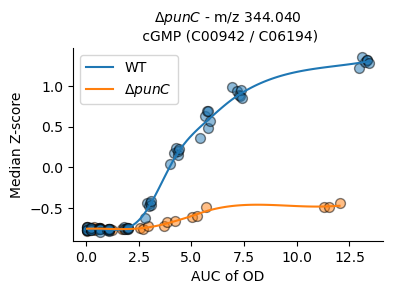

16.356379880396542 16.30310150119043 0.0 Valine 116.0718


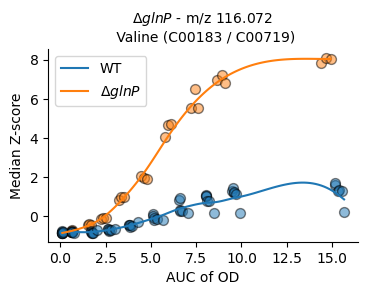

14.55772784853661 14.55772784853661 0.0 Oxoglutarate 145.0141


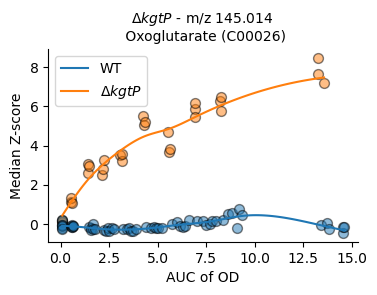

14.226583643553434 14.160707128189618 0.0 Hydroxybutanoic acid 103.04


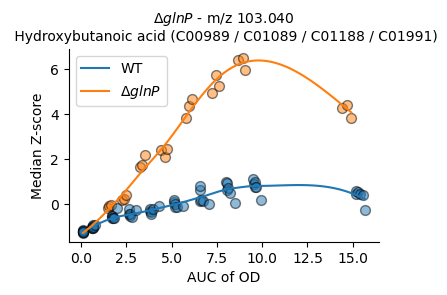

13.921372905279991 13.921372905279991 0.0 Aminobutanoic acid (ABA) 102.0562


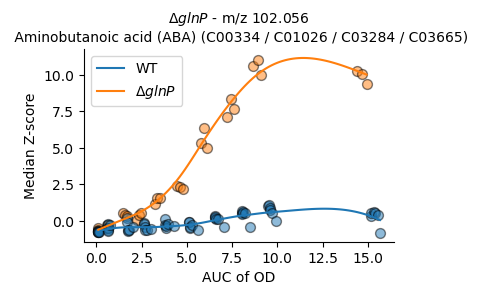

13.70781955342727 -13.683664485440318 0.0 Valine 116.0718


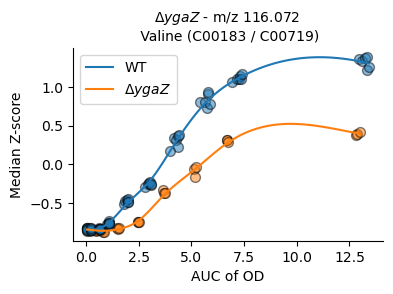

13.67819925943771 13.67819925943771 0.0 S-Ribosyl-L-homocysteine 266.0703


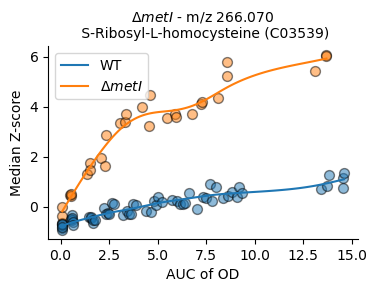

13.106362386650828 -13.049091057920094 0.0 CMP 322.0444


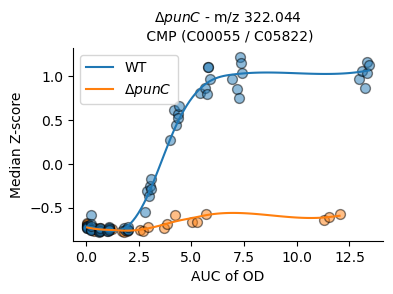

13.065258248204998 -13.065258248204998 0.0 (R) 2,3-Dihydroxy-3-methylvalerate 147.0664


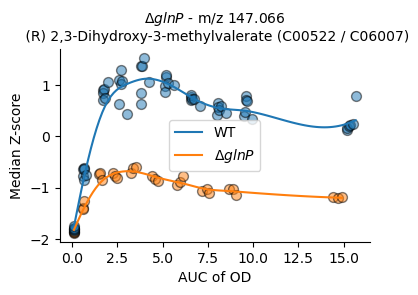

12.802219210926934 12.802219210926934 0.0 Proline 114.056


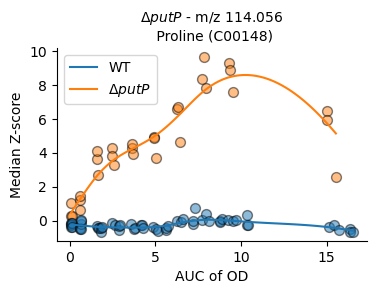

12.571661915391957 12.571661915391957 0.0 Orotate 155.0099


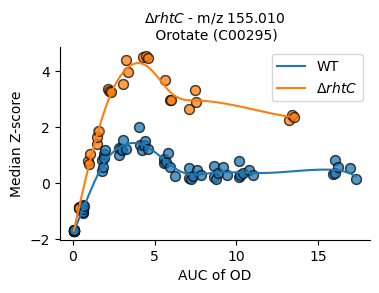

12.4181012494045 -12.4181012494045 0.0 Deoxyribose 133.0508


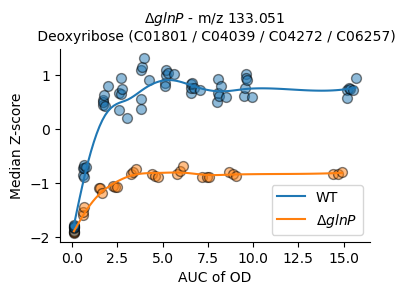

12.389385316793208 -12.183928406825888 0.0 GMP 362.0506


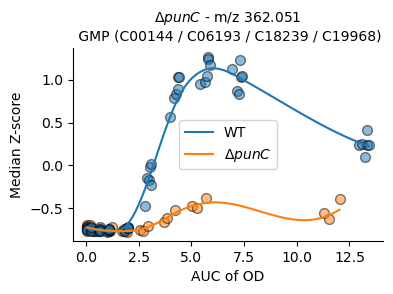

12.10745207851495 12.10745207851495 0.0 Uracil 111.0203


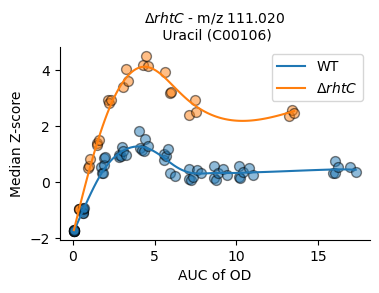

11.58239525114336 -10.579716167488057 0.0 3',5'-Cyclic CMP 304.0351


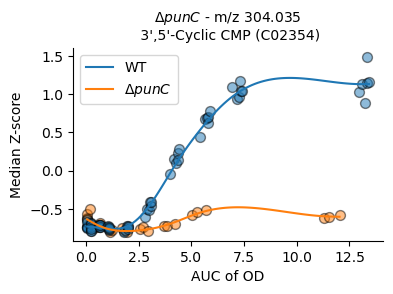

11.365911611026082 -11.313850987234334 0.0 Acetyl-Asp 174.0409


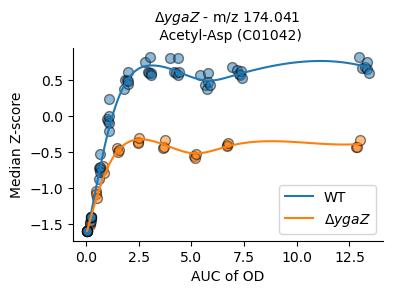

10.604611309478456 10.54470136213165 0.0 Acetyl-Glu 188.0566


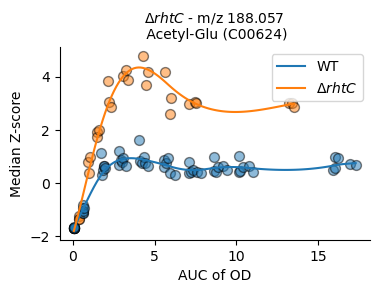

10.59267976567222 -10.459267930118726 0.0 cGMP 344.04


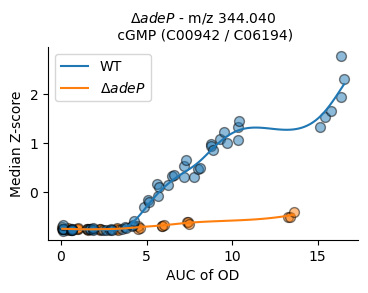

10.343581078078138 -10.343581078078138 0.0 dTDP-6-deoxy-beta-L-talose 547.0754


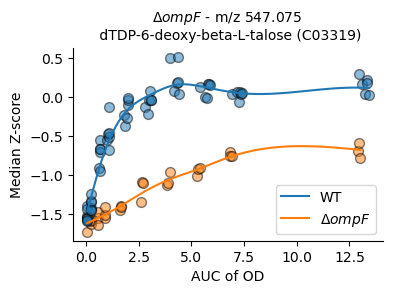

10.045373468005172 10.034978072236916 0.0 (Iso)Leucine 130.0876


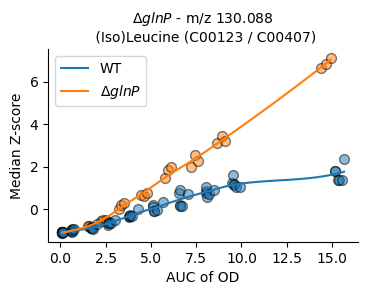

9.97578641350887 9.970862062665656 0.0 Acetyl-Asp 174.0409


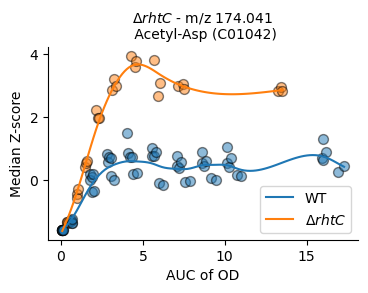

9.84519058494126 9.840072635035092 0.0 IMP 347.0398


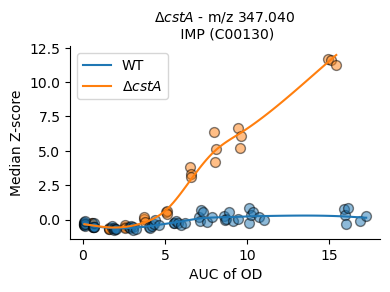

9.6677515261629 9.6677515261629 0.0 Ureidosuccinic acid 175.0364


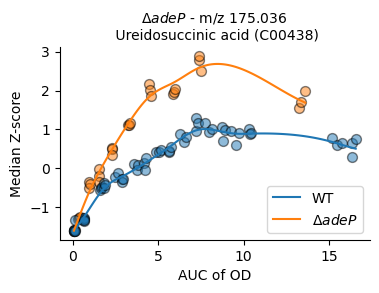

9.53745320325228 9.53745320325228 0.0 Pyridoxal 166.0507


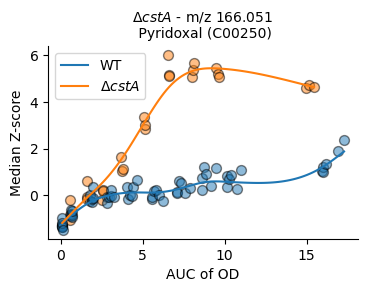

9.450708699218996 -8.786746626595267 0.0 3',5'-Cyclic AMP 328.0452


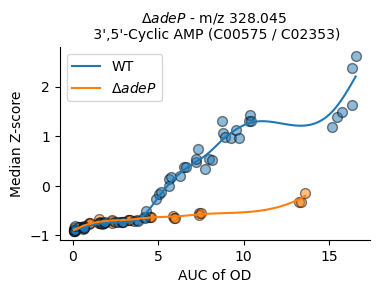

9.39035430335731 9.349347957839276 0.0 Pantothenate 218.1034


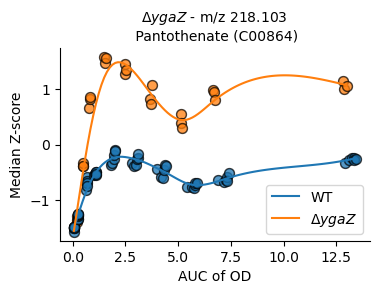

9.389308247549032 9.389308247549032 0.0 Aspartate 132.0305


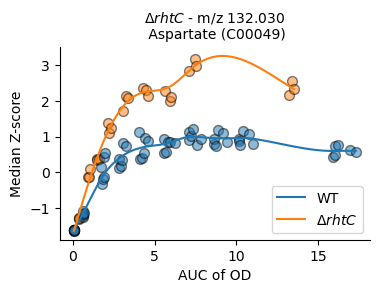

9.363082402286029 9.289962799172784 0.0 N-(2,3-Dihydroxybenzoyl)-L-serine 240.0514


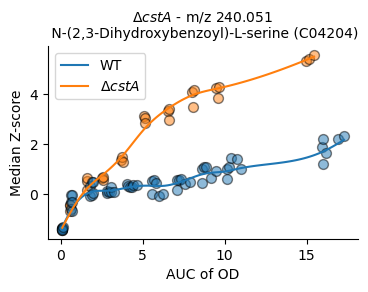

9.273941208150234 -9.273941208150234 0.0 Itaconate 129.0194


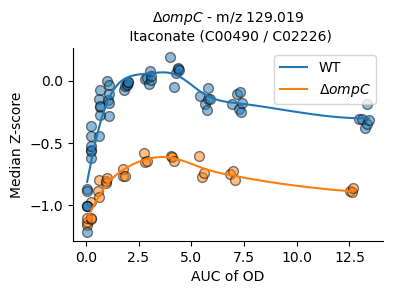

9.197182450947558 9.184186703373216 0.0 5-Aminolevulinic acid 130.0511


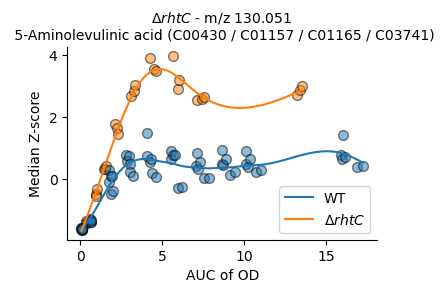

9.091884690657178 -9.062715807259217 0.0 CMP 322.0444


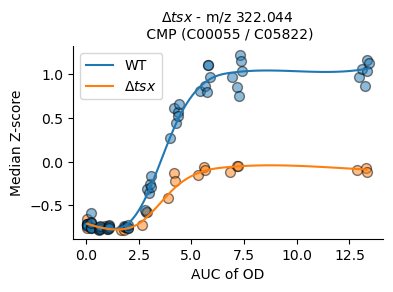

9.073738930482454 9.061620605733468 0.0 cGMP 344.04


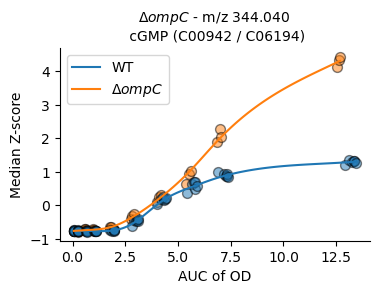

9.00494546901546 -8.66486589222732 0.0 UMP 323.0285


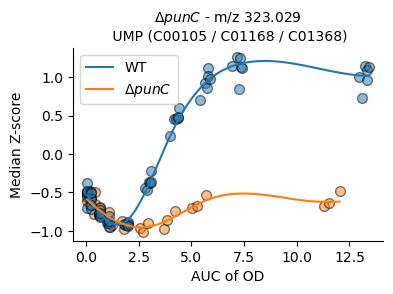

8.997312118791553 -8.833994683943093 0.0 3',5'-Cyclic AMP 328.0452


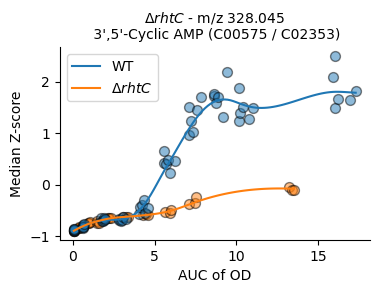

8.956055365016768 -8.80475640803434 0.0 CMP 322.0444


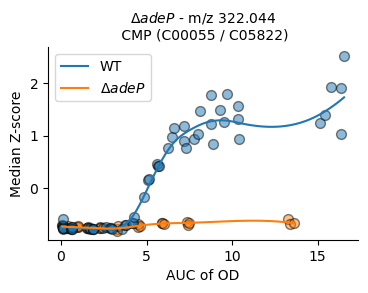

8.751946950707502 -8.751946950707502 0.0 3-Propylmalate 175.061


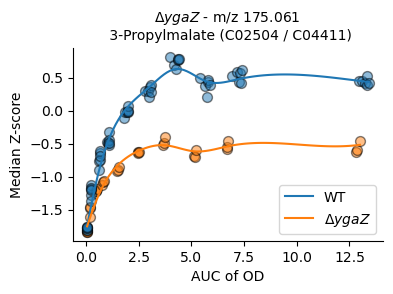

8.717221826583316 -8.692507555662369 0.0 GMP 362.0506


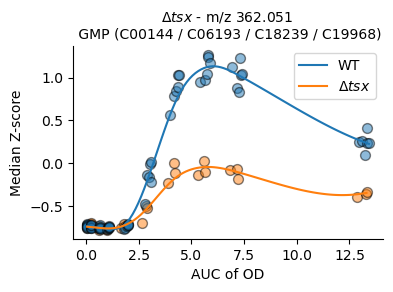

8.547973504379668 8.547973504379668 0.0 Aspartate 132.0305


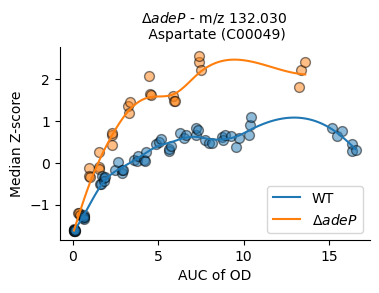

8.386862703849085 -8.386862703849085 0.0 (R) 2,3-Dihydroxy-3-methylvalerate 147.0664


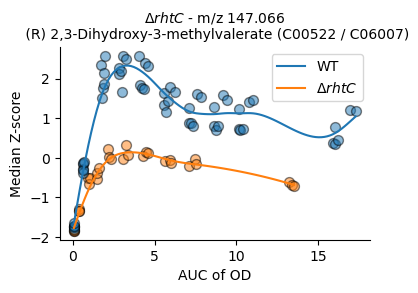

8.305979578398524 -8.19395175380599 0.0 5-Aminolevulinic acid 130.0511


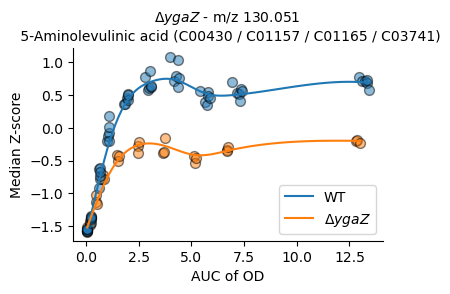

In [72]:
xval = 'AUC OD'
yval = 'Median Z-score'
ystd = 'Z-score std'

for i, row in dis_mz.loc[sel_idx].sort_values(by=['Rel. abs. distance'], ascending=False).head(40).iterrows():
    batch = df.loc[df.Strain == row['Strain'], 'Batch'].values[0]
    data = df.loc[(df.ionMz == row['ionMz'])&(df.Strain.isin(['WT', row['Strain']]))&(df['Batch'] == batch)].copy()
    print(row['Rel. abs. distance'], row['Rel. distance'], row['p-value rel'], row['Metabolite'], row['ionMz'])
    ionMz = row['ionMz']
    strain = row['Strain']
    is_duplicated = data[xval].duplicated()
    if np.any(is_duplicated):
        data.loc[is_duplicated, xval] += np.random.normal(0, 1e-3, size=is_duplicated.sum())
    data.sort_values(by=xval, inplace=True)
    x = data.loc[data.Strain == strain, xval].values
    y = data.loc[data.Strain == strain, yval].values
    y_std = data.loc[data.Strain == strain, ystd].values

    xwt = data.loc[data.Strain == 'WT', xval].values
    ywt = data.loc[data.Strain == 'WT', yval].values
    ywt_std = data.loc[data.Strain == 'WT', ystd].values

    spline = make_smoothing_spline(x, y, w = 1/y_std, lam = lam)
    spline_wt = make_smoothing_spline(xwt, ywt, w = 1/ywt_std, lam = lam)

    # x_common = np.linspace(max(x.min(), xwt.min()), min(x.max(), xwt.max()), 100, endpoint=True)
    xarr = np.linspace(x.min(), x.max(), 100, endpoint=True)
    xwtarr = np.linspace(xwt.min(), xwt.max(), 100, endpoint= True)

    fig, ax = plt.subplots(1, figsize=(4,2.5))
    ax.plot(xwtarr, spline_wt(xwtarr), label='WT', color='C0')
    ax.plot(xarr, spline(xarr), label=f'Δ${strain}$', color='C1')

    ax.scatter(x, y, color='C1', alpha=0.5, edgecolors='k', s=50)
    ax.scatter(xwt, ywt, color='C0', alpha=0.5, edgecolors='k', s=50)
    ax.set_title(f'Δ${strain}$ - m/z {ionMz:.3f} \n {row['Metabolite']} ({row['KEGG'].replace(";"," / ")})', size = 10)
    if xval == 'Hours':
        ax.set_xlabel('Time [h]')
    else:
        ax.set_xlabel('AUC of OD')
    ax.set_ylabel('Median Z-score')
    sns.despine()
    # plt.tight_layout()
    # plt.subplots_adjust(left=0.5, right=0.95)
    ax.legend()
    plt.savefig(timeseries_plots_folder / f'timeseries_{strain}_metabolite_{row["Metabolite"]}.png', dpi=300, bbox_inches='tight')
    plt.savefig(timeseries_plots_folder / f'timeseries_{strain}_metabolite_{row["Metabolite"]}.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()



# Plot bar charts

In [73]:
sel_df = dis_mz.loc[sel_idx].copy()

In [74]:
all_strains = dis_mz['Strain'].unique()
N_changed_mets = sel_df.groupby('Strain')['Metabolite'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_neg = sel_df.loc[sel_df['Rel. distance'] < 0].groupby('Strain')['Metabolite'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_pos = sel_df.loc[sel_df['Rel. distance'] > 0].groupby('Strain')['Metabolite'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)

In [75]:
met_changes = pd.merge(N_changed_mets_neg, N_changed_mets_pos, left_index=True, right_index=True, how='outer')
met_changes.columns = ['Decrease', 'Increase']
met_changes = met_changes.reset_index()
met_changes.dropna(inplace=True)

In [76]:
met_changes['Total'] = met_changes['Decrease'] + met_changes['Increase']

In [77]:
met_changes.sort_values(by='Total', ascending=False)

,Strain,Decrease,Increase,Total
2,adeP,25,36,61
41,punC,19,28,47
19,glnP,26,21,47
60,ygaZ,30,7,37
46,rhtC,11,24,35
...,...,...,...,...
25,hisQ,0,0,0
16,fruA,0,0,0
34,nupC,0,0,0
29,manY,0,0,0


In [78]:
met_changesL = met_changes.reset_index().melt(id_vars='Strain', var_name='Release', 
value_name='Number of changed metabolites', value_vars=['Increase', 'Decrease'])
met_changesL['Total'] = met_changesL.Strain.map(met_changes.set_index('Strain')['Total'].to_dict())

In [79]:
met_changes.sort_values(by=['Total', 'Strain'], ascending=[False, True], inplace=True)

In [80]:
ax.get_xticklabels()[0]

Text(-2.5, 0, '−2.5')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_74021/3240251657.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changes['Strain']], rotation=90)


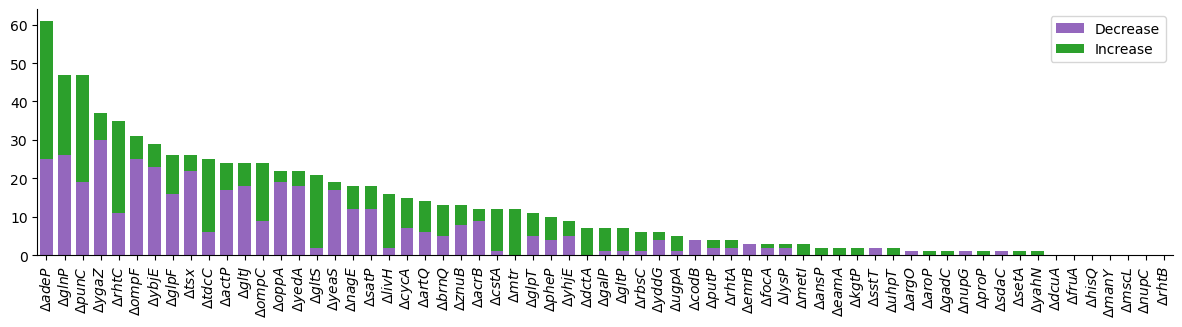

In [81]:
fig, ax = plt.subplots(figsize = (12,3))
bar_width = 0.7  # Adjust this value for wider/narrower bars

ax.bar(met_changes['Strain'], height = met_changes['Decrease'], width=bar_width, label='Decrease', color = 'C4')
ax.bar(met_changes['Strain'], height =  met_changes['Increase'], bottom=met_changes['Decrease'], width=bar_width, label='Increase', color = 'C2')
plt.xlim(-0.5, len(met_changes['Strain'])-0.5)
ax.legend()
plt.tight_layout()
ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changes['Strain']], rotation=90)
# ax.set_ylabel('Number of affected metabolites \n (Effect > %s and p-value < %s)'%(rel_dis_limit, p_val_limit))
sns.despine()
plt.show()


# Histograms

In [82]:
met_changes

,Strain,Decrease,Increase,Total
2,adeP,25,36,61
19,glnP,26,21,47
41,punC,19,28,47
60,ygaZ,30,7,37
46,rhtC,11,24,35
...,...,...,...,...
25,hisQ,0,0,0
29,manY,0,0,0
31,mscL,0,0,0
34,nupC,0,0,0


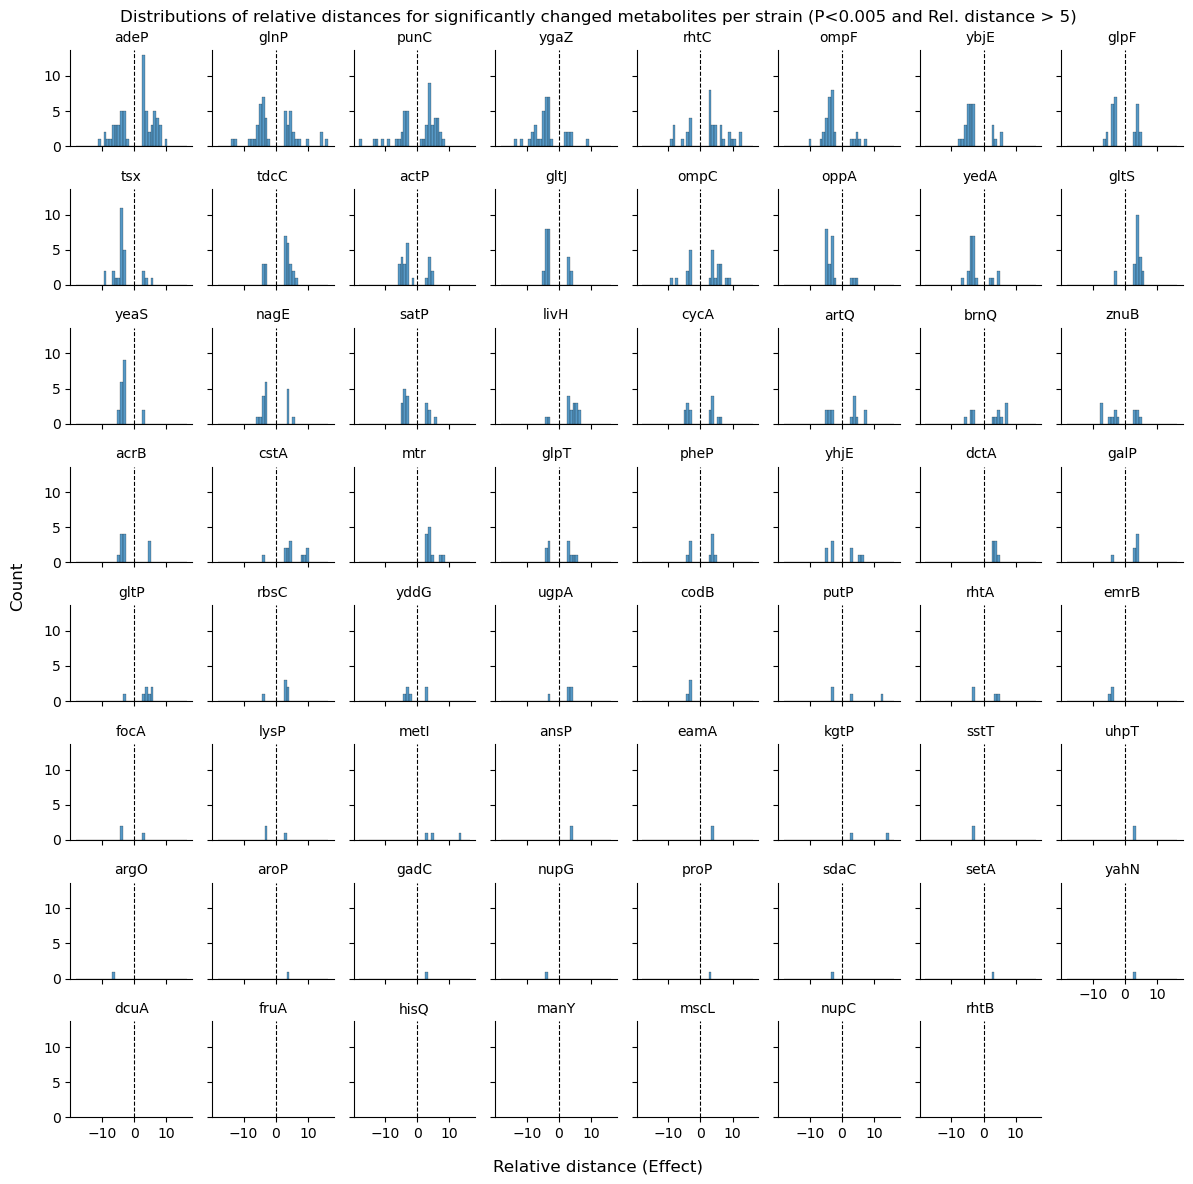

In [83]:
g = sns.displot(sel_df,  x='Rel. distance', col = 'Strain', 
                col_wrap=8, bins = 40, col_order=met_changes.Strain, height = 1.5)#, hue = 'Batch')
for ax in g.axes.flatten():
    ax.axvline(0, c = 'k', ls = '--', lw = 0.8)
    ax.set_xlabel('')
    ax.set_ylabel('')
g.set_titles(col_template = '{col_name}', size = 10)
g.fig.suptitle('Distributions of relative distances for significantly changed metabolites per strain (P<0.005 and Rel. distance > 5)')
g.fig.supxlabel(r'Relative distance (Effect)', y=0.01, fontsize=12)
g.fig.supylabel('Count', x=0.01, fontsize=12)
    # ax.annotate(0.05, 0.05, )
# plt.yscale('log')
plt.tight_layout()

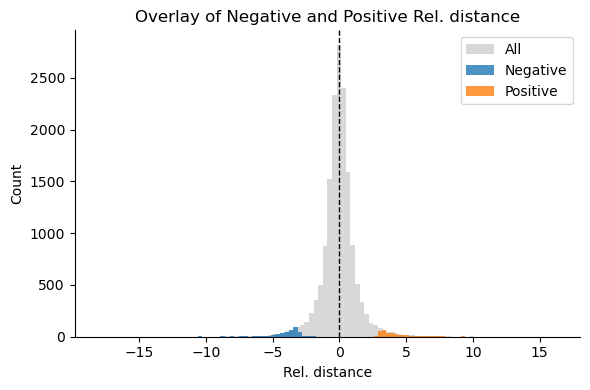

In [84]:
plt.figure(figsize=(6, 4))
data = sel_df['Rel. distance']

plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.3, color='grey', label='All')
plt.hist(data[data < 0], bins=50, alpha=0.8, color='C0', label='Negative')
plt.hist(data[data > 0], bins=50, alpha=0.8, color='C1', label='Positive')

plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Rel. distance')
plt.ylabel('Count')
plt.legend()
# plt.yscale('log')
plt.title('Overlay of Negative and Positive Rel. distance')
plt.tight_layout()
sns.despine()
plt.show()

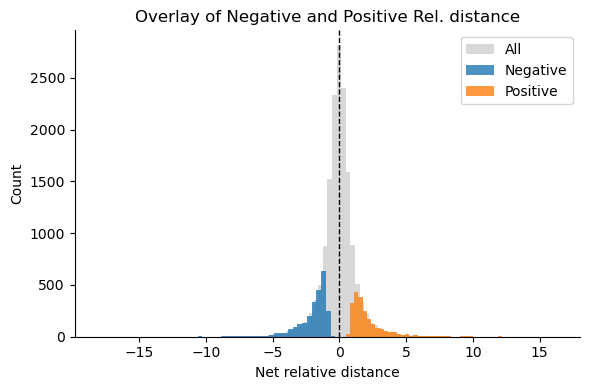

In [85]:
plt.figure(figsize=(6, 4))
data = dis_df.loc[dis_df['p-value rel'] < max_pval, 'Rel. distance']

plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.3, color='grey', label='All')
plt.hist(data[data < 0], bins=50, alpha=0.8, color='C0', label='Negative')
plt.hist(data[data > 0], bins=50, alpha=0.8, color='C1', label='Positive')

plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Net relative distance')
plt.ylabel('Count')
plt.legend()
# plt.yscale('log')
plt.title('Overlay of Negative and Positive Rel. distance')
plt.tight_layout()
sns.despine()
plt.show()

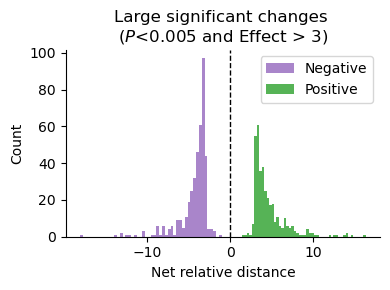

In [86]:
plt.figure(figsize=(4, 3))
data = sel_df['Rel. distance']

# plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.3, color='grey', label='All')
plt.hist(data[data < 0], bins=50, alpha=0.8, color='C4', label='Negative')
plt.hist(data[data > 0], bins=50, alpha=0.8, color='C2', label='Positive')

plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Net relative distance')
plt.ylabel('Count')
plt.legend()
# plt.yscale('log')
# plt.title('Overlay of Negative and Positive Rel. distance')
plt.title('Large significant changes \n($P$<%s and Effect > %s)'%(max_pval, min_effect))
plt.tight_layout()
sns.despine()
plt.show()

# Metabolite centric

In [87]:
all_metabolites = dis_mz['Metabolite'].unique()
N_changed_strains = sel_df.groupby('Metabolite')['Strain'].count().reindex(all_metabolites, fill_value=0).sort_values(ascending=False)
N_changed_strains_neg = sel_df.loc[sel_df['Rel. distance'] < 0].groupby('Metabolite')['Strain'].count().reindex(all_metabolites, fill_value=0).sort_values(ascending=False)
N_changed_strains_pos = sel_df.loc[sel_df['Rel. distance'] > 0].groupby('Metabolite')['Strain'].count().reindex(all_metabolites, fill_value=0).sort_values(ascending=False)

In [88]:
strain_changes = pd.merge(N_changed_strains_neg, N_changed_strains_pos, left_index=True, right_index=True, how='outer')
strain_changes.columns = ['Decrease', 'Increase']
strain_changes = strain_changes.reset_index()
strain_changes.dropna(inplace=True)

In [89]:
strain_changes['Total'] = strain_changes['Decrease'] + strain_changes['Increase']

In [90]:
strain_changesL = strain_changes.reset_index().melt(id_vars='Metabolite', var_name='Release', 
value_name='Number of changed metabolites', value_vars=['Increase', 'Decrease'])
strain_changesL['Total'] = strain_changesL.Metabolite.map(strain_changes.set_index('Metabolite')['Total'].to_dict())

In [91]:
strain_changes.sort_values(by=['Total', 'Metabolite'], ascending=[False, True], inplace=True)

In [92]:
strain_changes = strain_changes[strain_changes['Total'] > 0]

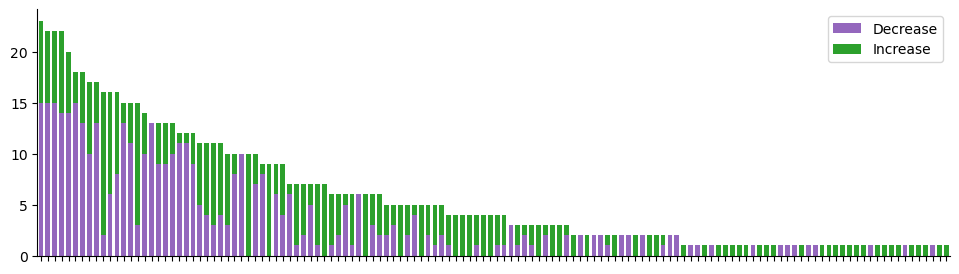

In [93]:
fig, ax = plt.subplots(figsize = (12,3))
bar_width = 0.7  # Adjust this value for wider/narrower bars

ax.bar(strain_changes['Metabolite'], height = strain_changes['Decrease'], width=bar_width, label='Decrease', color = 'C4')
ax.bar(strain_changes['Metabolite'], height =  strain_changes['Increase'], bottom=strain_changes['Decrease'], width=bar_width, label='Increase', color = 'C2')
plt.xlim(-0.5, len(strain_changes['Metabolite'])-0.5)
ax.legend()
plt.tight_layout()
# ax.set_xticklabels([lbl for lbl in strain_changes['Metabolite']], rotation=90, size = 6)
ax.set_xticklabels([])
# ax.set_ylabel('Number of affected metabolites \n (Effect > %s and p-value < %s)'%(rel_dis_limit, p_val_limit))
sns.despine()
plt.show()

16.356379880396542 16.30310150119043 0.0 Valine 116.0718


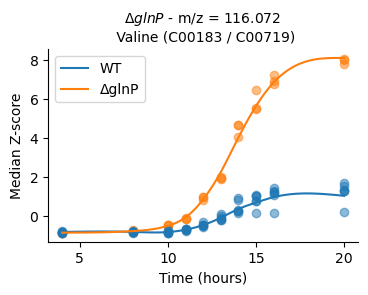

14.226583643553434 14.160707128189618 0.0 Hydroxybutanoic acid 103.04


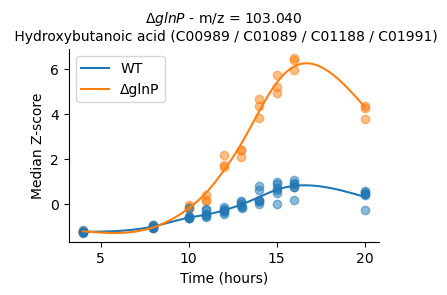

13.921372905279991 13.921372905279991 0.0 Aminobutanoic acid (ABA) 102.0562


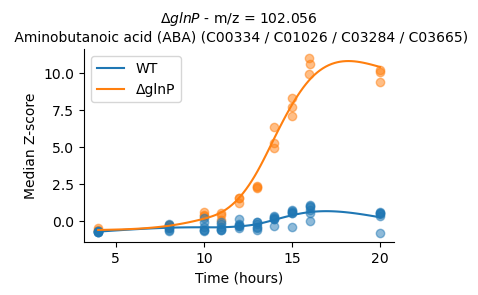

10.045373468005172 10.034978072236916 0.0 (Iso)Leucine 130.0876


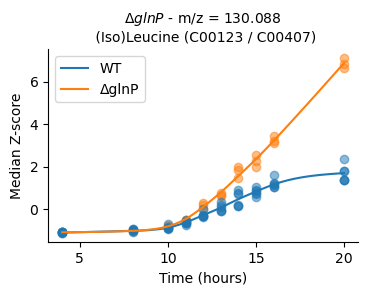

7.455470359037814 7.455470359037814 0.0 2,3,4,5-Tetrahydrodipicolinate 170.0454


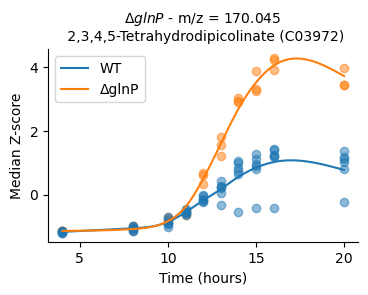

6.180385801735173 6.180385801735173 0.0 Alanine 88.0406


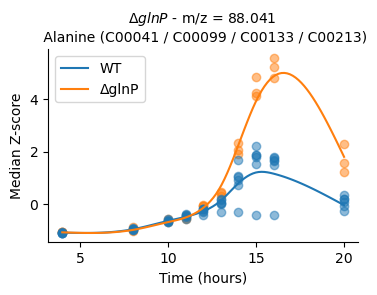

5.5704599588727275 5.5704599588727275 0.0 Glutamine 145.0621


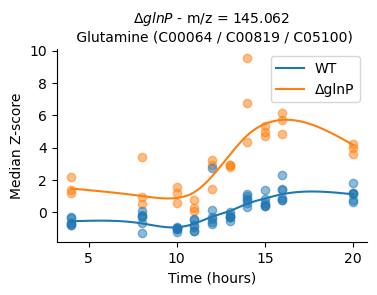

5.282495160573901 5.282495160573901 0.0 Acetyl-Glu 188.0566


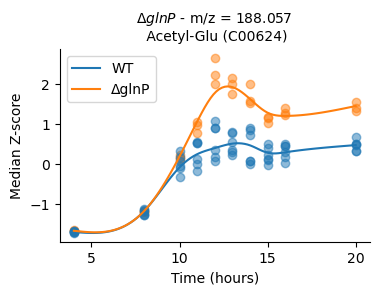

5.096972667140534 5.056651962006761 0.0 Lactate 89.0247


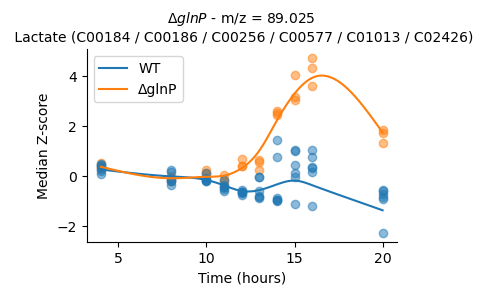

5.228956134116109 5.02017111146925 0.0 2-Deoxy-D-ribose 1-phosphate 213.0161


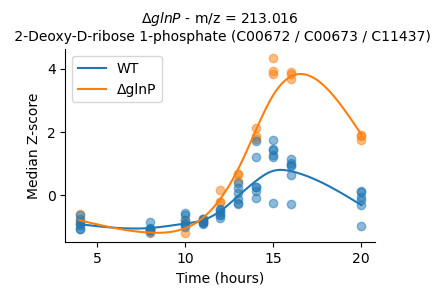

In [94]:
xval = 'Hours'
yval = 'Median Z-score'
ystd = 'Z-score std'

for i, row in sel_df.loc[sel_df.Strain == 'glnP'].sort_values(by='Rel. distance', ascending=False).head(10).iterrows():
    batch = df.loc[df.Strain == row['Strain'], 'Batch'].values[0]
    data = df.loc[(df.ionMz == row['ionMz'])&(df.Strain.isin(['WT', row['Strain']]))&(df['Batch'] == batch)].copy()
    print(row['Rel. abs. distance'], row['Rel. distance'], row['p-value rel'], row['Metabolite'], row['ionMz'])
    ionMz = row['ionMz']
    strain = row['Strain']
    is_duplicated = data[xval].duplicated()
    if np.any(is_duplicated):
        data.loc[is_duplicated, xval] += np.random.normal(0, 1e-3, size=is_duplicated.sum())
    data.sort_values(by=xval, inplace=True)
    x = data.loc[data.Strain == strain, xval].values
    y = data.loc[data.Strain == strain, yval].values
    y_std = data.loc[data.Strain == strain, ystd].values

    xwt = data.loc[data.Strain == 'WT', xval].values
    ywt = data.loc[data.Strain == 'WT', yval].values
    ywt_std = data.loc[data.Strain == 'WT', ystd].values

    spline = make_smoothing_spline(x, y, w = 1/y_std, lam = lam)
    spline_wt = make_smoothing_spline(xwt, ywt, w = 1/ywt_std, lam = lam)

    x_common = np.linspace(max(x.min(), xwt.min()), min(x.max(), xwt.max()), 100, endpoint=True)

    fig, ax = plt.subplots(1, figsize=(4,2.5))
    ax.plot(x_common, spline_wt(x_common), label='WT', color='C0')
    ax.plot(x_common, spline(x_common), label=f'Δ{strain}', color='C1')

    ax.scatter(x, y, color='C1', alpha=0.5)
    ax.scatter(xwt, ywt, color='C0', alpha=0.5)
    ax.set_title(f'Δ${strain}$ - m/z = {ionMz:.3f} \n {row['Metabolite']} ({row['KEGG'].replace(";"," / ")})', size = 10)
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Median Z-score')
    sns.despine()
    # plt.tight_layout()
    # plt.subplots_adjust(left=0.5, right=0.95)
    ax.legend()
    plt.savefig(timeseries_plots_folder / f'timeseries_{strain}_metabolite_{row["Metabolite"]}.png', dpi=300, bbox_inches='tight')
    plt.savefig(timeseries_plots_folder / f'timeseries_{strain}_metabolite_{row["Metabolite"]}.pdf', dpi=300)
    
    plt.show()



In [95]:
sel_glnP = sel_df.loc[sel_df.Strain == 'glnP']
len(sel_glnP.loc[sel_glnP['Rel. distance'] > 0])

21